In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from collections import Counter
from tqdm import tqdm
import re
import gc
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Enable memory growth for GPU
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [ ]:
class Config:
    # HTMLPhish specifications
    CHAR_SEQ_LEN = 180      # Character sequence length (HTMLPhish spec)
    WORD_SEQ_LEN = 2000     # Word sequence length (HTMLPhish spec)

    # Embedding dimensions
    EMBEDDING_DIM = 100     # HTMLPhish spec: 100 dimensions

    # CNN parameters (HTMLPhish spec)
    NUM_FILTERS = 64        # HTMLPhish spec: 32 filters
    KERNEL_SIZE = 8         # HTMLPhish spec: kernel size 8
    POOL_SIZE = 2           # HTMLPhish spec: pool size 2

    # Training parameters
    BATCH_SIZE = 20         # HTMLPhish spec: batch size 20
    LEARNING_RATE = 0.0015  # HTMLPhish spec: 0.0015
    EPOCHS = 40              # Adjustable
    DROPOUT_RATE = 0.5      # HTMLPhish spec: 0.5

    # Dense layer parameters
    DENSE_UNITS = 10        # HTMLPhish spec: 10 units

    # Special tokens
    UNK_TOKEN = '<UNK>'
    PAD_TOKEN = '<PAD>'

    # Vocabulary thresholds
    MIN_CHAR_FREQ = 1
    MIN_WORD_FREQ = 1

config = Config()

In [ ]:
class MemoryEfficientHTMLPreprocessor:
    def __init__(self, max_vocab_size=50000):
        self.char_to_id = {}
        self.word_to_id = {}
        self.max_vocab_size = max_vocab_size
        self.char_tokenizer = None
        self.word_tokenizer = None

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({
                'char_to_id': self.char_to_id,
                'word_to_id': self.word_to_id,
                'max_vocab_size': self.max_vocab_size
            }, f)
        print(f"Preprocessor saved to {path}")

    def load(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)

        preprocessor = MemoryEfficientHTMLPreprocessor(max_vocab_size=data.get('max_vocab_size', 50000))
        preprocessor.char_to_id = data['char_to_id']
        preprocessor.word_to_id = data['word_to_id']
        print(f"Preprocessor loaded from {path}")
        return preprocessor

    def load_data_streaming_xlsx(self, file_path, html_column='html', label_column='label', max_samples=None):
        """Load URL data from Excel file"""
        print("Loading URL data from Excel file...")

        try:
            # Read Excel file
            df = pd.read_excel(file_path)
            print(f"Excel file loaded with {len(df)} rows and columns: {list(df.columns)}")

            # Check if specified columns exist
            if html_column not in df.columns:
                print(f"Warning: Column '{html_column}' not found. Available columns: {list(df.columns)}")
                # Try to find URL column automatically
                possible_url_cols = [col for col in df.columns if 'url' in col.lower()]
                if possible_url_cols:
                    html_column = possible_url_cols[0]
                    print(f"Using column '{html_column}' as URL column")
                else:
                    raise ValueError("No URL column found")

            if label_column not in df.columns:
                print(f"Warning: Column '{label_column}' not found. Available columns: {list(df.columns)}")
                # Try to find label column automatically
                possible_label_cols = [col for col in df.columns if any(term in col.lower() for term in ['label', 'class', 'target', 'type'])]
                if possible_label_cols:
                    label_column = possible_label_cols[0]
                    print(f"Using column '{label_column}' as label column")
                else:
                    raise ValueError("No label column found")

            # Extract HTMLs and labels
            htmls = df[html_column].astype(str).tolist()
            labels = df[label_column].tolist()

            # Handle different label formats
            unique_labels = set(labels)
            print(f"Unique labels found: {unique_labels}")

            # Convert labels to binary (0/1)
            if unique_labels == {0, 1} or unique_labels == {'0', '1'}:
                labels = [int(label) for label in labels]
            elif len(unique_labels) == 2:
                # Map to 0 and 1
                label_mapping = {list(unique_labels)[0]: 0, list(unique_labels)[1]: 1}
                labels = [label_mapping[label] for label in labels]
                print(f"Label mapping applied: {label_mapping}")
            else:
                raise ValueError(f"Expected binary labels, got: {unique_labels}")

            # Remove any NaN or empty HTMLs
            valid_indices = [i for i, url in enumerate(htmls) if pd.notna(url) and str(url).strip() != '']
            htmls = [htmls[i] for i in valid_indices]
            labels = [labels[i] for i in valid_indices]

            # Limit samples if specified
            if max_samples and len(htmls) > max_samples:
                htmls = htmls[:max_samples]
                labels = labels[:max_samples]

            print(f"Loaded {len(htmls)} valid HTMLs")
            print(f"Benign HTMLs: {labels.count(0)}")
            print(f"Malicious HTMLs: {labels.count(1)}")

            return htmls, labels

        except Exception as e:
            print(f"Error loading Excel data: {e}")
            return [], []

    def preprocess_html(self, html_text):
        """Convert HTML to string and preprocess"""
        html_str = str(html_text)
        return html_str

    def extract_characters(self, html_text):
        """Extract character sequence from HTML"""
        html_str = self.preprocess_html(html_text)
        return list(html_str.lower()[:config.CHAR_SEQ_LEN])

    def extract_words(self, html_text):
        """Extract word sequence from HTML, treating punctuation as separate tokens"""
        html_str = self.preprocess_html(html_text)

        tokens = re.findall(r'\w+|[^\w\s]', html_str.lower())
        tokens = [token for token in tokens if token.strip()]
        return tokens[:config.WORD_SEQ_LEN]

    def build_vocabularies_efficient(self, texts, sample_size=20000):
        print("Building vocabularies...")

        if len(texts) > sample_size:
            sample_indices = np.random.choice(len(texts), sample_size, replace=False)
            sample_texts = [texts[i] for i in sample_indices]
        else:
            sample_texts = texts

        char_counter = Counter()
        word_counter = Counter()

        # Count in batches to save memory
        batch_size = 1000
        for i in tqdm(range(0, len(sample_texts), batch_size), desc="Building vocabularies"):
            batch_texts = sample_texts[i:i+batch_size]

            for html_text in batch_texts:
                chars = self.extract_characters(html_text)
                words = self.extract_words(html_text)

                char_counter.update(chars)
                word_counter.update(words)

            # Clear batch from memory
            del batch_texts
            if i % 5000 == 0:
                gc.collect()

        # Build character vocabulary
        self.char_to_id = {config.PAD_TOKEN: 0, config.UNK_TOKEN: 1}
        most_common_chars = char_counter.most_common()

        for char, count in most_common_chars:
            if count >= config.MIN_CHAR_FREQ and len(self.char_to_id) < self.max_vocab_size:
                self.char_to_id[char] = len(self.char_to_id)

        # Build word vocabulary
        self.word_to_id = {config.PAD_TOKEN: 0, config.UNK_TOKEN: 1}
        most_common_words = word_counter.most_common()

        for word, count in most_common_words:
            if count >= config.MIN_WORD_FREQ and len(self.word_to_id) < self.max_vocab_size:
                self.word_to_id[word] = len(self.word_to_id)

        print(f"Character vocabulary size: {len(self.char_to_id)}")
        print(f"Word vocabulary size: {len(self.word_to_id)}")

        # Clean up
        del char_counter, word_counter, sample_texts
        gc.collect()

    def encode_html_batch(self, texts):
        """Encode a batch of HTML texts efficiently"""
        batch_size = len(texts)

        # Initialize arrays
        char_sequences = np.zeros((batch_size, config.CHAR_SEQ_LEN), dtype=np.int32)
        word_sequences = np.zeros((batch_size, config.WORD_SEQ_LEN), dtype=np.int32)

        for i, html_text in enumerate(texts):
            # Character sequence
            chars = self.extract_characters(html_text)
            for j, char in enumerate(chars[:config.CHAR_SEQ_LEN]):
                char_sequences[i, j] = self.char_to_id.get(char, self.char_to_id[config.UNK_TOKEN])

            # Word sequence
            words = self.extract_words(html_text)
            for j, word in enumerate(words[:config.WORD_SEQ_LEN]):
                word_sequences[i, j] = self.word_to_id.get(word, self.word_to_id[config.UNK_TOKEN])

        return char_sequences, word_sequences

In [ ]:
def create_htmlphish_model(char_vocab_size, word_vocab_size):
    """Create HTMLPhish-Full model following the exact specifications"""

    # Input layers
    char_input = layers.Input(shape=(config.CHAR_SEQ_LEN,), name='char_input')
    word_input = layers.Input(shape=(config.WORD_SEQ_LEN,), name='word_input')

    # Character embedding (HTMLPhish spec: 100 dimensions)
    char_embedding = layers.Embedding(
        char_vocab_size,
        config.EMBEDDING_DIM,
        input_length=config.CHAR_SEQ_LEN,
        name='char_embedding'
    )(char_input)

    # Word embedding (HTMLPhish spec: 100 dimensions)
    word_embedding = layers.Embedding(
        word_vocab_size,
        config.EMBEDDING_DIM,
        input_length=config.WORD_SEQ_LEN,
        name='word_embedding'
    )(word_input)

    # Concatenation Layer
    # Results in (2180, 100) matrix
    concatenated = layers.Concatenate(axis=1, name='concatenate')([char_embedding, word_embedding])

    # Convolutional Layer
    conv = layers.Conv1D(
        filters=config.NUM_FILTERS,
        kernel_size=config.KERNEL_SIZE,
        activation='relu',
        name='conv1d'
    )(concatenated)

    # Max Pooling Layer
    pool = layers.MaxPooling1D(pool_size=config.POOL_SIZE, name='max_pooling')(conv)
    flatten = layers.Flatten(name='flatten')(pool)

    # Dense Layer
    dense = layers.Dense(config.DENSE_UNITS, activation='relu', name='dense')(flatten)
    dropout = layers.Dropout(config.DROPOUT_RATE, name='dropout')(dense)

    # Output Layer
    output = layers.Dense(1, activation='sigmoid', name='output')(dropout)

    # Create model
    model = Model(
        inputs=[char_input, word_input],
        outputs=output,
        name='HTMLPhish-Full'
    )

    return model

In [ ]:
class SimpleHTMLDataGenerator:
    """Simple data generator for HTML data"""

    def __init__(self, texts, labels, preprocessor, batch_size, shuffle=True):
        self.texts = texts
        self.labels = labels
        self.preprocessor = preprocessor
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.num_batches = len(texts) // batch_size
        self.reset()

    def reset(self):
        """Reset the generator for a new epoch"""
        self.indices = np.arange(len(self.texts))
        if self.shuffle:
            np.random.shuffle(self.indices)
        self.current_batch = 0

    def __iter__(self):
        return self

    def __next__(self):
        if self.current_batch >= self.num_batches:
            raise StopIteration

        start_idx = self.current_batch * self.batch_size
        end_idx = min(start_idx + self.batch_size, len(self.texts))

        batch_indices = self.indices[start_idx:end_idx]
        batch_texts = [self.texts[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        # Encode batch
        char_seq, word_seq = self.preprocessor.encode_html_batch(batch_texts)
        batch_labels = np.array(batch_labels, dtype=np.float32)

        self.current_batch += 1
        return [char_seq, word_seq], batch_labels

    def __len__(self):
        return self.num_batches

In [ ]:
def train_model_with_generator(model, train_gen, val_gen, epochs):
    """Manual training loop with progress bars"""
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')

        # Training with progress bar
        train_gen.reset()
        epoch_loss = 0
        epoch_acc = 0
        batch_count = 0

        # Training progress bar
        train_pbar = tqdm(total=len(train_gen), desc="Training",
                         bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] Loss: {postfix[0]:.4f}, Acc: {postfix[1]:.4f}',
                         postfix=[0.0, 0.0])

        for batch_x, batch_y in train_gen:
            # Train on batch
            metrics = model.train_on_batch(batch_x, batch_y)
            epoch_loss += metrics[0]
            epoch_acc += metrics[1]
            batch_count += 1

            # Update progress bar
            train_pbar.postfix[0] = metrics[0]  # Current batch loss
            train_pbar.postfix[1] = metrics[1]  # Current batch accuracy
            train_pbar.update(1)

        train_pbar.close()

        # Average metrics
        epoch_loss /= batch_count
        epoch_acc /= batch_count

        # Validation with progress bar
        val_gen.reset()
        val_loss = 0
        val_acc = 0
        val_batch_count = 0

        # Validation progress bar
        val_pbar = tqdm(total=len(val_gen), desc="Validation",
                       bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] Loss: {postfix[0]:.4f}, Acc: {postfix[1]:.4f}',
                       postfix=[0.0, 0.0])

        for batch_x, batch_y in val_gen:
            metrics = model.test_on_batch(batch_x, batch_y)
            val_loss += metrics[0]
            val_acc += metrics[1]
            val_batch_count += 1

            # Update progress bar
            val_pbar.postfix[0] = metrics[0]  # Current batch loss
            val_pbar.postfix[1] = metrics[1]  # Current batch accuracy
            val_pbar.update(1)

        val_pbar.close()

        val_loss /= val_batch_count
        val_acc /= val_batch_count

        # Store history
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch Summary - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')

    return history

In [ ]:
def evaluate_on_test_set(model, preprocessor, test_texts, test_labels, batch_size=20, title_prefix = "Test"):
    """Evaluate the model on the test set with progress bar"""
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)
    print("Note: This is the first and only time the test set is being used!")

    # Encode test data in batches to manage memory
    test_size = len(test_texts)
    all_predictions = []
    all_true_labels = []
    all_probabilities = []

    total_loss = 0
    total_accuracy = 0
    num_batches = (test_size + batch_size - 1) // batch_size

    print(f"Evaluating on {test_size} test samples...")

    # Test evaluation progress bar
    test_pbar = tqdm(total=num_batches, desc="Testing",
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] Loss: {postfix[0]:.4f}, Acc: {postfix[1]:.4f}',
                    postfix=[0.0, 0.0])

    batch_idx = 0
    for i in range(0, test_size, batch_size):
        end_idx = min(i + batch_size, test_size)
        batch_texts = test_texts[i:end_idx]
        batch_labels = test_labels[i:end_idx]

        # Encode batch
        char_seq, word_seq = preprocessor.encode_html_batch(batch_texts)
        batch_y = np.array(batch_labels, dtype=np.float32)

        # Evaluate batch
        batch_metrics = model.test_on_batch([char_seq, word_seq], batch_y)
        total_loss += batch_metrics[0]
        total_accuracy += batch_metrics[1]

        # Get predictions for this batch
        batch_predictions = model.predict([char_seq, word_seq], verbose=0)

        # Store raw probabilities
        all_probabilities.extend(batch_predictions.flatten())

        # Convert to binary predictions for metrics
        batch_pred_labels = (batch_predictions.flatten() > 0.5).astype(int)
        all_predictions.extend(batch_pred_labels)
        all_true_labels.extend(batch_labels)

        batch_idx += 1

        # Update progress bar
        test_pbar.postfix[0] = batch_metrics[0]  # Current batch loss
        test_pbar.postfix[1] = batch_metrics[1]  # Current batch accuracy
        test_pbar.update(1)

    test_pbar.close()

    # Calculate final metrics
    final_test_loss = total_loss / num_batches
    final_test_accuracy = total_accuracy / num_batches

    print(f"\nFINAL TEST RESULTS:")
    print(f"Test Loss: {final_test_loss:.4f}")
    print(f"Test Accuracy: {final_test_accuracy:.4f}")

    # Classification report
    print("\nDetailed Classification Report:")
    print(classification_report(all_true_labels, all_predictions,
                              target_names=['Legitimate', 'Phishing'],
                              digits=4))
    # Add ROC AUC below the classification report
    test_auc = roc_auc_score(all_true_labels, all_probabilities)
    print(f"ROC AUC: {test_auc:.4f}")

    return final_test_loss, final_test_accuracy, all_predictions, all_true_labels, np.array(all_probabilities)

In [ ]:
def fetch_html_from_url(url):
    """Fetch HTML content from a URL using BeautifulSoup"""
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        # Use BeautifulSoup to parse and extract HTML
        soup = BeautifulSoup(response.content, 'html.parser')
        html_text = str(soup)

        return html_text
    except Exception as e:
        print(f"Error fetching HTML from {url}: {e}")
        return None

def predict_single_webpage(model, preprocessor, url=None, html_content=None):
    """Predict a single webpage from URL or HTML content"""
    if html_content is None:
        if url is None:
            print("Either URL or HTML content must be provided")
            return None

        print(f"Fetching HTML from: {url}")
        html_content = fetch_html_from_url(url)

        if html_content is None:
            print("Failed to fetch HTML content")
            return None

    # Encode the HTML
    char_seq, word_seq = preprocessor.encode_html_batch([html_content])

    # Make prediction
    prediction = model.predict([char_seq, word_seq], verbose=0)
    probability = prediction[0][0]

    if url:
        print(f"\nPrediction for {url}:")
    else:
        print(f"\nPrediction for provided HTML:")

    print(f"Probability of being phishing: {probability:.4f}")
    print(f"Classification: {'PHISHING' if probability > 0.5 else 'LEGITIMATE'}")

    # Show confidence
    confidence = max(probability, 1 - probability)
    print(f"Confidence: {confidence:.4f}")

    return probability

In [ ]:
def test_on_external_dataset(model, preprocessor, file_path, output_path):
    # Load external dataset
    htmls, labels = preprocessor.load_data_streaming_xlsx(file_path)

    if not htmls:
        print("No data found in the external dataset.")
        return

    print(f"Loaded external dataset with {len(htmls)} samples")

    # Encode data batch
    char_seq, word_seq = preprocessor.encode_html_batch(htmls)

    # Run predictions
    predictions = model.predict([char_seq, word_seq], verbose=1).flatten()
    binary_preds = (predictions > 0.5).astype(int)

    # Calculate accuracy
    accuracy = accuracy_score(labels, binary_preds)
    print(f"Accuracy on external dataset: {accuracy * 100:.2f}%")

    # Prepare DataFrame
    results_df = pd.DataFrame({
        "HTML": htmls,
        "True_Label": labels,
        "Predicted_Label": binary_preds,
        "Prediction_Probability": predictions
    })

    # Save results to Excel
    results_df.to_excel(output_path, index=False)
    print(f"Results saved to {output_path}")

    return results_df, accuracy

In [ ]:
def build_model_from_preprocessor(preprocessor):
    model = create_htmlphish_model(
        len(preprocessor.char_to_id),
        len(preprocessor.word_to_id)
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

def load_artifacts(model_path, preproc_path):
    preprocessor = MemoryEfficientHTMLPreprocessor.load(preproc_path)
    model = build_model_from_preprocessor(preprocessor)
    model.load_weights(model_path)
    print("Model weights loaded.")
    return model, preprocessor

def evaluate_saved_on_dataset(model_path, preproc_path, dataset_path, batch_size=20, title_prefix="Saved Model"):
    model, preprocessor = load_artifacts(model_path, preproc_path)
    htmls, labels = preprocessor.load_data_streaming_xlsx(dataset_path)

    if not htmls:
        print("No data to evaluate.")
        return

    return evaluate_on_test_set(model, preprocessor, htmls, labels, batch_size)

def predict_single_with_saved(model_path, preproc_path, url=None, html_content=None):
    model, preprocessor = load_artifacts(model_path, preproc_path)
    return predict_single_webpage(model, preprocessor, url, html_content)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score

def plot_test_metrics(y_true, y_proba, y_pred=None, title_prefix="Test"):
    """
    Generate requested plots and metrics using test labels and predicted probabilities.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    if y_pred is None:
        y_pred = (y_proba > 0.5).astype(int)
    else:
        y_pred = np.asarray(y_pred).astype(int)

    # 1) Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malicious'],
                yticklabels=['Benign', 'Malicious'])
    plt.title(f'{title_prefix} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # 2) Precision–Recall Curve
    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label='PR curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} - Precision–Recall Curve')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Precision/Recall/F1 vs Confidence (quantile-binned)
    # Sweep bins and merge if too small
    # --- Confidence curves with quantile bins ---
    n_bins = 20
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(y_proba, quantiles)
    bin_ids = np.digitize(y_proba, bins, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins-1)

    bin_centers, binned_precision, binned_recall, binned_f1 = [], [], [], []

    for b in range(n_bins):
        idx = np.where(bin_ids == b)[0]
        if idx.size == 0:
            # No samples in this bin, use previous bin's values if possible
            if len(bin_centers) > 0:
                bin_centers.append(bin_centers[-1])
                binned_precision.append(binned_precision[-1])
                binned_recall.append(binned_recall[-1])
                binned_f1.append(binned_f1[-1])
            continue

        p = y_proba[idx]
        t = y_true[idx]

        pred_bin = (p > 0.5).astype(int)
        tp = np.sum((pred_bin == 1) & (t == 1))
        fp = np.sum((pred_bin == 1) & (t == 0))
        fn = np.sum((pred_bin == 0) & (t == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        bin_centers.append(p.mean())
        binned_precision.append(precision)
        binned_recall.append(recall)
        binned_f1.append(f1)

    bin_centers = np.array(bin_centers)
    binned_precision = np.array(binned_precision)
    binned_recall = np.array(binned_recall)
    binned_f1 = np.array(binned_f1)

    # Precision vs Confidence
    plt.figure(figsize=(6,5))
    plt.plot(bin_centers, binned_precision, marker='o', linestyle='-')  # line with points
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} - Precision vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Recall vs Confidence
    plt.figure(figsize=(6,5))
    plt.plot(bin_centers, binned_recall, marker='o', linestyle='-', color='orange')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('Recall')
    plt.title(f'{title_prefix} - Recall vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # F1 vs Confidence
    plt.figure(figsize=(6,5))
    plt.plot(bin_centers, binned_f1, marker='o', linestyle='-', color='green')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('F1-score')
    plt.title(f'{title_prefix} - F1 vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) ROC Curve + AUC
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {auc_val:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title_prefix} - ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Metrics summary at the operating point
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision_score_final = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_score_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_final = 2 * (precision_score_final * recall_score_final) / (precision_score_final + recall_score_final) if (precision_score_final + recall_score_final) > 0 else 0

    print(f"\n{'='*50}")
    print(f"METRICS SUMMARY FOR {title_prefix}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision_score_final:.4f}")
    print(f"Recall: {recall_score_final:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1_final:.4f}")
    print(f"ROC AUC: {auc_val:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision_score_final,
        'recall': recall_score_final,
        'specificity': specificity,
        'f1_score': f1_final,
        'roc_auc': auc_val,
        'confusion_matrix': cm
    }

In [ ]:
def main():
    # Set random seeds
    np.random.seed(42)
    tf.random.set_seed(42)

    # Clear any previous session
    tf.keras.backend.clear_session()
    gc.collect()

    # Dataset path
    TRAIN_DATA_PATH = '/content/drive/MyDrive/Thesis/html_d1.xlsx'
    TEST_DATA_PATH = '/content/drive/MyDrive/Thesis/html_d3.xlsx'

    # Artifacts
    MODEL_PATH = '/content/drive/MyDrive/Final_Thesis/htmlphish_model.keras'
    PREPROC_PATH = '/content/drive/MyDrive/Final_Thesis/htmlphish_preprocessor.pkl'

    # Initialize preprocessor
    preprocessor = MemoryEfficientHTMLPreprocessor(max_vocab_size=50000)

    # Load data
    print("Loading training data...")
    train_val_texts, train_val_labels = preprocessor.load_data_streaming_xlsx(TRAIN_DATA_PATH)

    if not train_val_texts:
        print("Failed to load training data. Please check the file path.")
        # Returning None will cause the TypeError in the calling cell
        return None, None, None

    # Split html_d1.xlsx into train and validation only (80% train, 20% validation)
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_val_texts, train_val_labels, test_size=0.2, random_state=42, stratify=train_val_labels
    )

    # Load test data (html_d3.xlsx)
    print("Loading test data...")
    test_texts, test_labels = preprocessor.load_data_streaming_xlsx(TEST_DATA_PATH)

    if not test_texts:
        print("Failed to load test data. Please check the file path.")
        # Returning None will cause the TypeError in the calling cell
        return None, None, None


    print(f"Training samples: {len(train_texts)}")
    print(f"Validation samples: {len(val_texts)}")
    print(f"Test samples: {len(test_texts)}")

    # Build vocabularies
    preprocessor.build_vocabularies_efficient(train_texts)

    # Create model
    print("Creating HTMLPhish-Full model...")
    model = create_htmlphish_model(
        len(preprocessor.char_to_id),
        len(preprocessor.word_to_id)
    )

    # Compile with HTMLPhish specifications
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='binary_crossentropy',  # Binary classification with sigmoid
        metrics=['accuracy']
    )

    print(f"Model parameters: {model.count_params():,}")
    model.summary()

    # Create data generators
    train_generator = SimpleHTMLDataGenerator(
        train_texts, train_labels, preprocessor, config.BATCH_SIZE, shuffle=True
    )

    val_generator = SimpleHTMLDataGenerator(
        val_texts, val_labels, preprocessor, config.BATCH_SIZE, shuffle=False
    )

    # Train model
    print("Training HTMLPhish model...")
    history = train_model_with_generator(model, train_generator, val_generator, config.EPOCHS)

    # Save artifacts
    model.save(MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")
    preprocessor.save(PREPROC_PATH)

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Final evaluation on test set
    test_loss, test_accuracy, test_predictions, test_true_labels, test_probabilities = evaluate_on_test_set(
        model, preprocessor, test_texts, test_labels, config.BATCH_SIZE, title_prefix="HTMLPhish"
    )

    # Generate comprehensive plots
    metrics = plot_test_metrics(
        test_true_labels,
        test_probabilities,
        test_predictions,
        title_prefix="HTMLPhish"
    )

    external_results = test_on_external_dataset(
        model,
        preprocessor,
        "/content/drive/MyDrive/Thesis/html_d2.xlsx",
        "/content/drive/MyDrive/Final_Thesis/html_results_d2.xlsx"
    )

    external_results2 = test_on_external_dataset(
        model,
        preprocessor,
        "/content/drive/MyDrive/Thesis/html_d3.xlsx",
        "/content/drive/MyDrive/Final_Thesis/html_results_d3.xlsx"
    )

    return model, preprocessor, history

Training:  53%|█████▎    | 427/800 [01:20<01:10,  5.29it/s] Loss: 0.2567, Acc: 0.8480


Loading training data...
Loading URL data from Excel file...
Excel file loaded with 20000 rows and columns: ['label', 'html']
Unique labels found: {0, 1}
Loaded 20000 valid HTMLs
Benign HTMLs: 10000
Malicious HTMLs: 10000
Loading test data...
Loading URL data from Excel file...
Excel file loaded with 9373 rows and columns: ['label', 'html']
Unique labels found: {0, 1}
Loaded 9373 valid HTMLs
Benign HTMLs: 4687
Malicious HTMLs: 4686
Training samples: 16000
Validation samples: 4000
Test samples: 9373
Building vocabularies efficiently...


Building vocabularies: 100%|██████████| 16/16 [00:42<00:00,  2.65s/it]


Character vocabulary size: 371
Word vocabulary size: 50000
Creating HTMLPhish-Full model...
Model parameters: 5,783,425


Model: "HTMLPhish-Full"

...

Epoch Summary - Loss: 0.1320 - Acc: 0.9757 - Val Loss: 0.1322 - Val Acc: 0.9758

Epoch 39/40


Validation: 100%|██████████| 200/200 [00:13<00:00, 14.77it/s] Loss: 0.1329, Acc: 0.9759


Epoch Summary - Loss: 0.1321 - Acc: 0.9758 - Val Loss: 0.1323 - Val Acc: 0.9759

Epoch 40/40


Validation: 100%|██████████| 200/200 [00:13<00:00, 14.84it/s] Loss: 0.1336, Acc: 0.9760


Epoch Summary - Loss: 0.1321 - Acc: 0.9760 - Val Loss: 0.1326 - Val Acc: 0.9760
Model saved to /content/drive/MyDrive/Final_Thesis/htmlphish_model.keras
Preprocessor saved to /content/drive/MyDrive/Final_Thesis/htmlphish_preprocessor.pkl


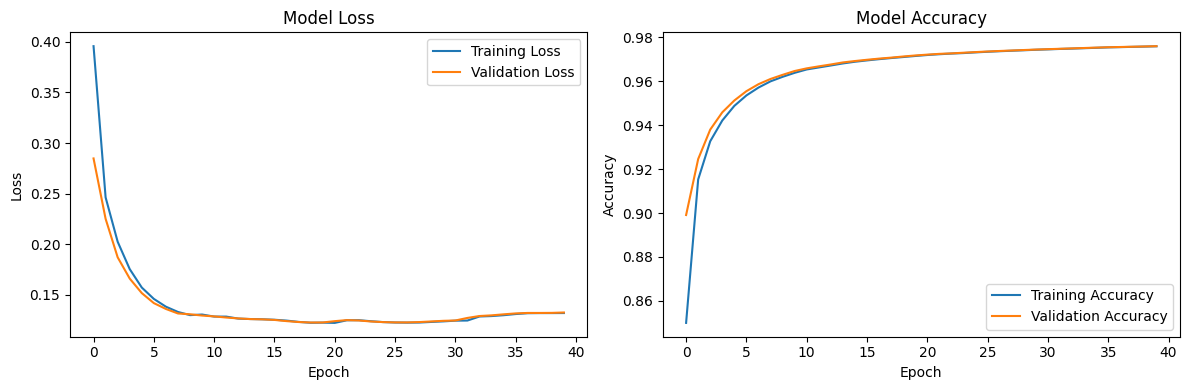


FINAL EVALUATION ON TEST SET
Note: This is the first and only time the test set is being used!
Evaluating on 9373 test samples...


Testing: 100%|██████████| 469/469 [01:08<00:00,  6.85it/s] Loss: 0.1421, Acc: 0.9759


FINAL TEST RESULTS:
Test Loss: 0.1379
Test Accuracy: 0.9760

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9518    0.9861    0.9687      4687
    Phishing     0.9856    0.9501    0.9675      4686

    accuracy                         0.9681      9373
   macro avg     0.9687    0.9681    0.9681      9373
weighted avg     0.9687    0.9681    0.9681      9373

ROC AUC: 0.9906


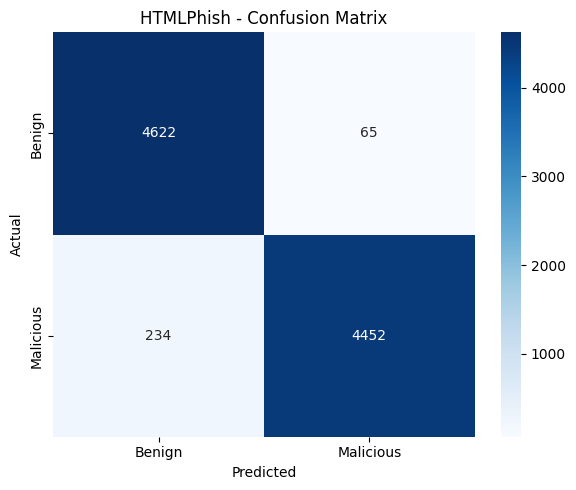

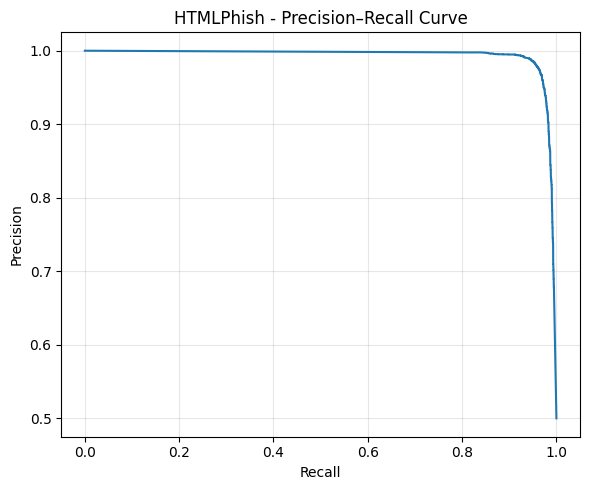

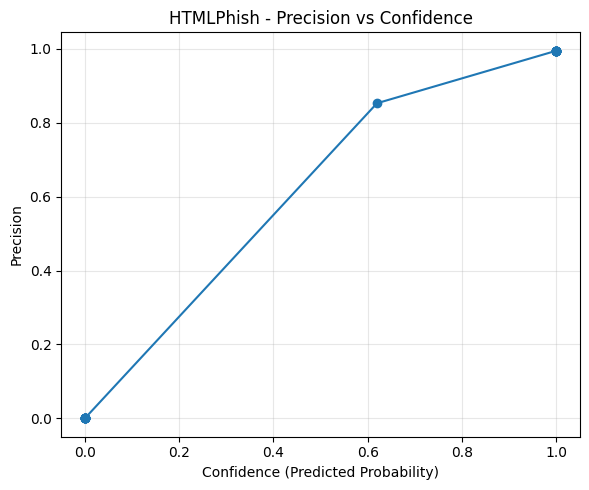

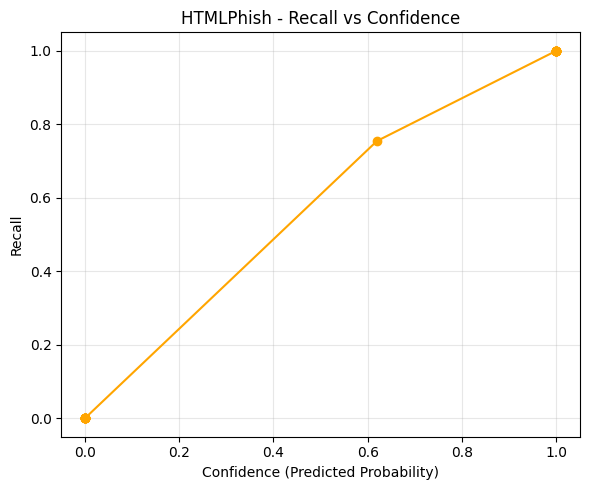

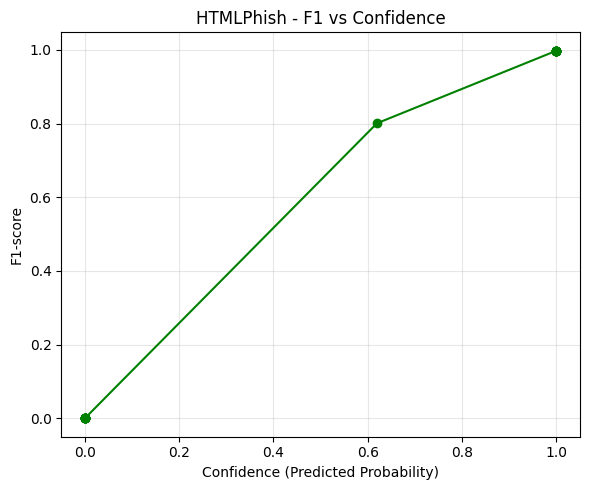

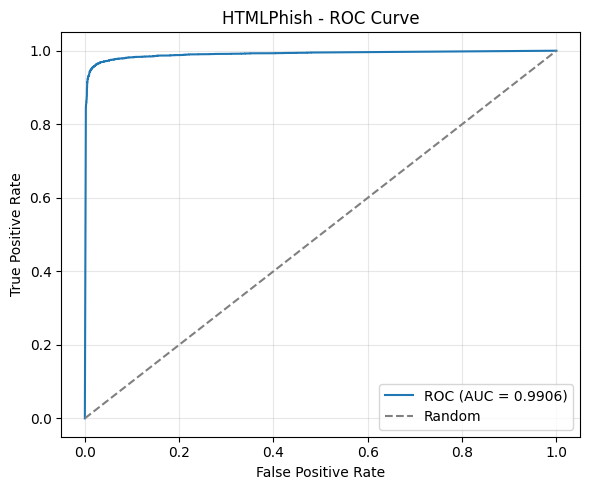


METRICS SUMMARY FOR HTMLPhish
Accuracy: 0.9681
Precision: 0.9856
Recall: 0.9501
Specificity: 0.9861
F1 Score: 0.9675
ROC AUC: 0.9906
Loading URL data from Excel file...
Excel file loaded with 16000 rows and columns: ['label', 'html']
Unique labels found: {0, 1}
Loaded 16000 valid HTMLs
Benign HTMLs: 8000
Malicious HTMLs: 8000
Loaded external dataset with 16000 samples
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy on external dataset: 97.12%
Results saved to /content/drive/MyDrive/Final_Thesis/html_results_d2.xlsx
Loading URL data from Excel file...
Excel file loaded with 9373 rows and columns: ['label', 'html']
Unique labels found: {0, 1}
Loaded 9373 valid HTMLs
Benign HTMLs: 4687
Malicious HTMLs: 4686
Loaded external dataset with 9373 samples
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy on external dataset: 96.81%
Results saved to /content/drive/MyDrive/Final_Thesis/html_results_d3.xlsx


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
if __name__ == "__main__":
    model, preprocessor, history = main()
    print("\nHTMLPhish model training and testing completed!")

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/Final_Thesis/htmlphish_model.keras'
PREPROC_PATH = '/content/drive/MyDrive/Final_Thesis/htmlphish_preprocessor.pkl'

Testing saved model on html_d3.xlsx...
Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/htmlphish_preprocessor.pkl
Model weights loaded.
Loading URL data from Excel file...
Excel file loaded with 9373 rows and columns: ['label', 'html']
Unique labels found: {0, 1}
Loaded 9373 valid HTMLs
Benign HTMLs: 4687
Malicious HTMLs: 4686

FINAL EVALUATION ON TEST SET
Note: This is the first and only time the test set is being used!
Evaluating on 9373 test samples...


Testing: 100%|██████████| 469/469 [01:17<00:00,  6.07it/s] Loss: 0.8611, Acc: 0.9681


FINAL TEST RESULTS:
Test Loss: 0.8376
Test Accuracy: 0.9684

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9518    0.9861    0.9687      4687
    Phishing     0.9856    0.9501    0.9675      4686

    accuracy                         0.9681      9373
   macro avg     0.9687    0.9681    0.9681      9373
weighted avg     0.9687    0.9681    0.9681      9373

ROC AUC: 0.9906


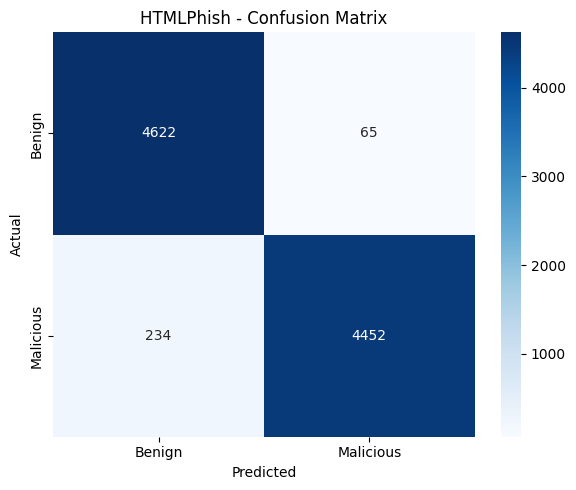

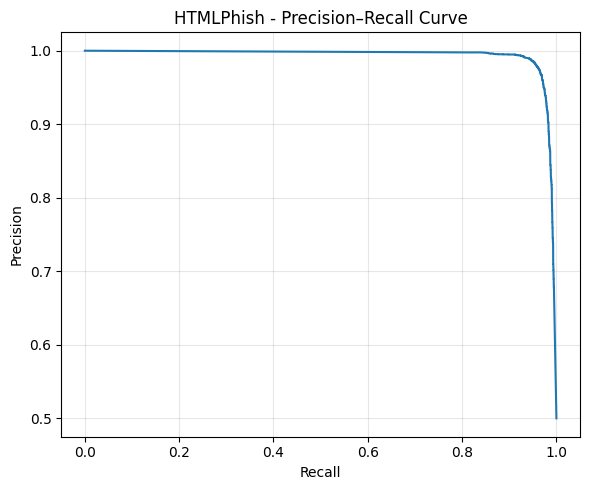

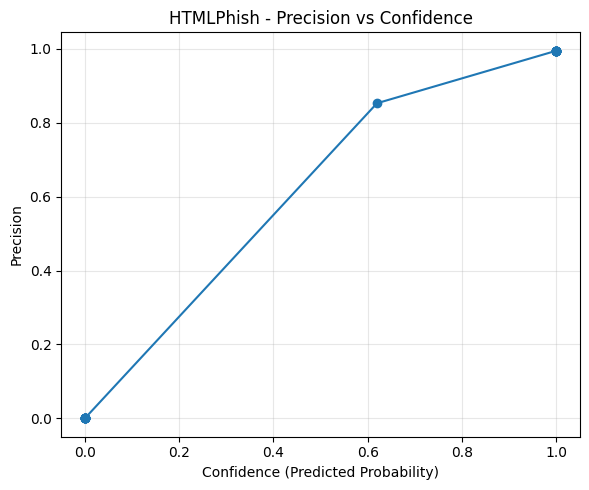

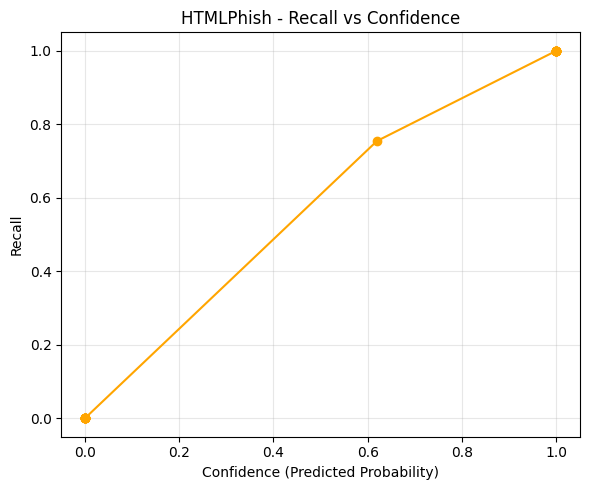

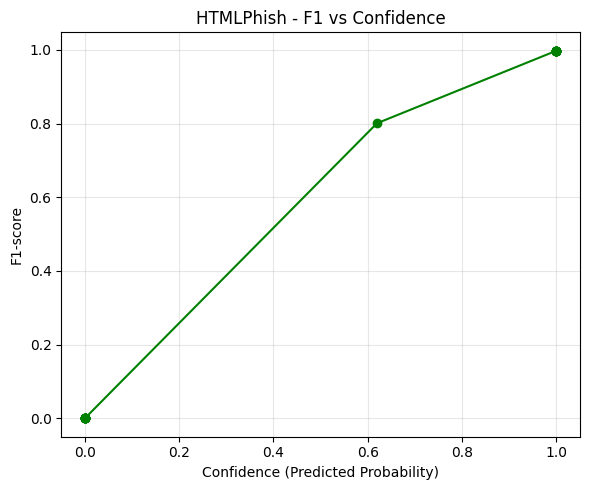

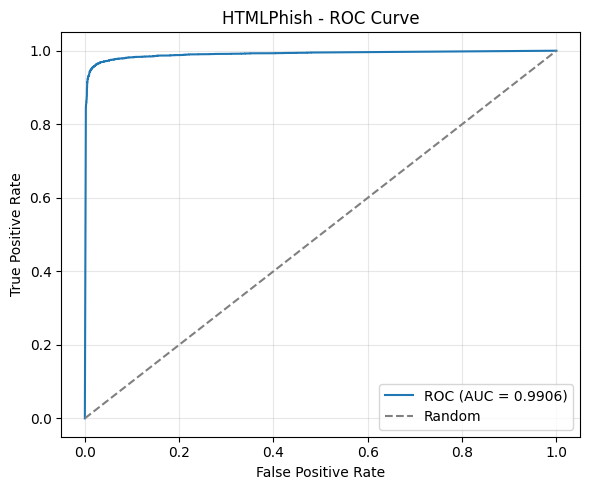


METRICS SUMMARY FOR HTMLPhish
Accuracy: 0.9681
Precision: 0.9856
Recall: 0.9501
Specificity: 0.9861
F1 Score: 0.9675
ROC AUC: 0.9906


In [ ]:
# Test saved model on d3 dataset
print("Testing saved model on html_d3.xlsx...")
test_loss, test_accuracy, test_predictions, test_true_labels, test_probabilities = evaluate_saved_on_dataset(
    MODEL_PATH,
    PREPROC_PATH,
    '/content/drive/MyDrive/Thesis/html_d3.xlsx',
    batch_size=20,
    title_prefix="Saved Model - d3"
)

metrics = plot_test_metrics(
    test_true_labels,
    test_probabilities,
    test_predictions,
    title_prefix="HTMLPhish"
)

In [ ]:
user_url = input("Enter the URL: ")

predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    user_url
)

Enter the URL: https://app.outlier.ai/expert
Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/htmlphish_preprocessor.pkl
Model weights loaded.
Fetching HTML from: https://app.outlier.ai/expert



Prediction for https://app.outlier.ai/expert:
Probability of being phishing: 0.0000
Classification: LEGITIMATE
Confidence: 1.0000


np.float32(4.6035526e-16)

In [ ]:
predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    url="https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray"
)

Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/htmlphish_preprocessor.pkl
Model weights loaded.
Fetching HTML from: https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray

Prediction for https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray:
Probability of being phishing: 0.0000
Classification: LEGITIMATE
Confidence: 1.0000


np.float32(0.0)